In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource

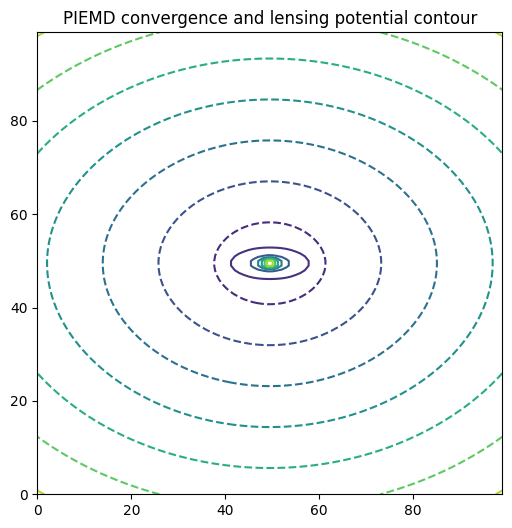

In [ ]:
src = DiskSource(100, 10)
df = PIEMD(source=src, theta_E=1.0, q=0.4, s=0, phi=0)

kappa = df.get_convergence()
psi = df.get_potential()

plt.figure(figsize=(6,6))
plt.contour(kappa)
plt.contour(psi, linestyles="--")
plt.title("PIEMD convergence and lensing potential contour")
plt.show()

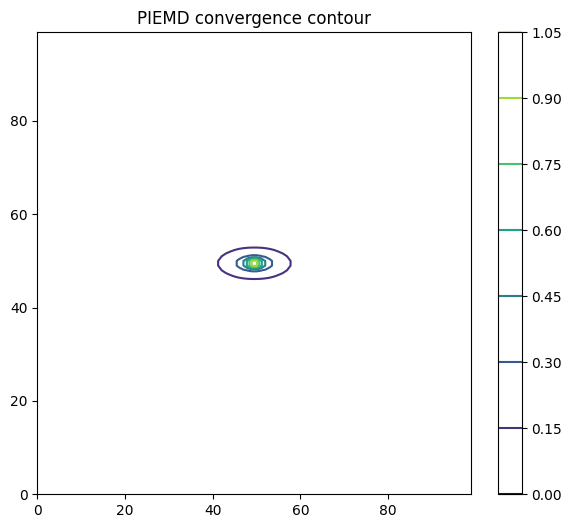

In [ ]:
plt.figure(figsize=(7,6))
cbar = plt.contour(kappa)
plt.colorbar(cbar)
plt.title("PIEMD convergence contour")
plt.show()

In [ ]:
src = DiskSource(50, 2)
# src.pad()
df = PIEMD(source=src, theta_E=10 ,q=1, s=0, phi=0)

img = df.get_image()

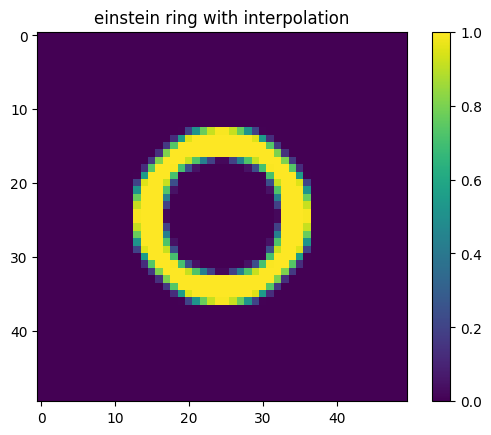

In [ ]:
cbar = plt.imshow(img)
plt.colorbar(cbar)
plt.title("einstein ring with interpolation")
plt.savefig("figures_out/interpolate_example.png")
plt.show()

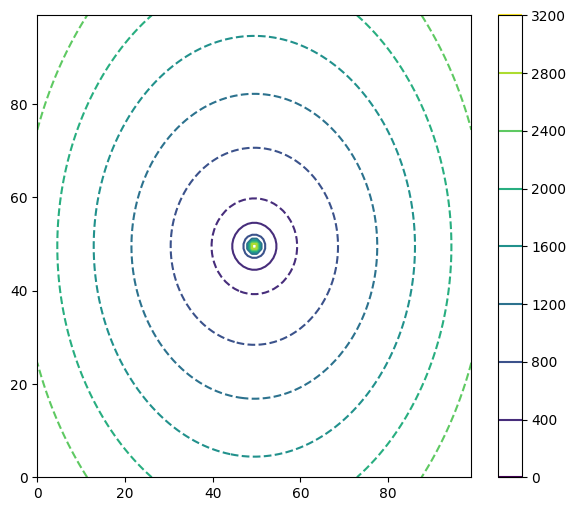

In [ ]:
plt.figure(figsize=(7,6))
src = DiskSource(100, 10)
df = PIEMD(source=src, theta_E=40, gamma_1=0.1, gamma_2=0)
kappa = df.get_convergence()
phi = df.get_potential()

plt.contour(kappa)
cbar = plt.contour(phi, linestyles="--")
plt.colorbar(cbar)
plt.show()

In [ ]:
src = DiskSource(1001, 300)
src.pad(1000)
df = PIEMD(source=src, theta_E=400, gamma_1=-0.2, gamma_2=0.1)

img = df.get_image()

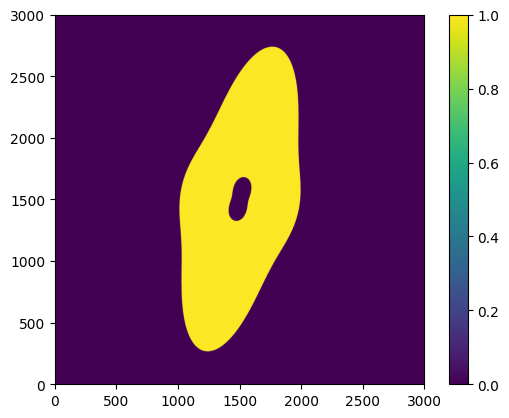

In [ ]:
cbar = plt.imshow(img, origin="lower")
plt.colorbar(cbar)
plt.show()

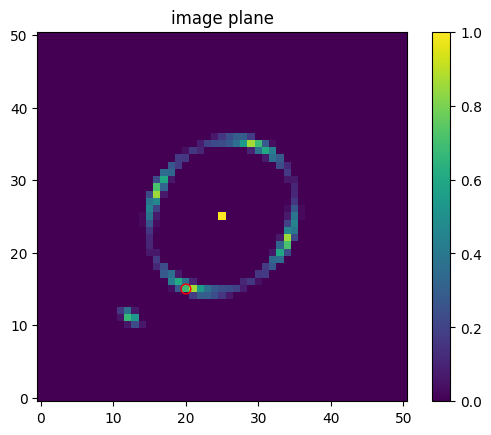

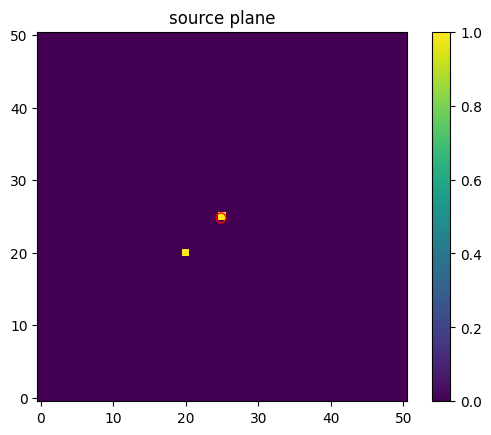

In [ ]:
arr = np.zeros((51,51))
arr[25,25] = 1
arr[20,20] = 1
src = Source(arr)
df = PIEMD(src, theta_E=10, q=0.8, s=1, gamma_1=0.01, gamma_2=0.03)

img = df.get_image()

cbar = plt.imshow(img, origin="lower")
plt.colorbar(cbar)

y_vec, x_vec = np.where(img > 0.5)
i = np.random.randint(x_vec.shape)
x, y = x_vec[i], y_vec[i]

r = [x,y]
beta_x, beta_y = df.map(r)
plt.scatter(x=x, y=y, facecolors='none', edgecolors='red', s=50)  # s controls size
plt.title("image plane")
plt.savefig("figures_out/ray_tracing_image.png")
plt.show()

cbar = plt.imshow(arr, origin="lower")
plt.colorbar(cbar)
plt.scatter(x=beta_x, y=beta_y, facecolors="none", edgecolors="red", s=50)
plt.title("source plane")
plt.savefig("figures_out/ray_tracing_source.png")
plt.show()

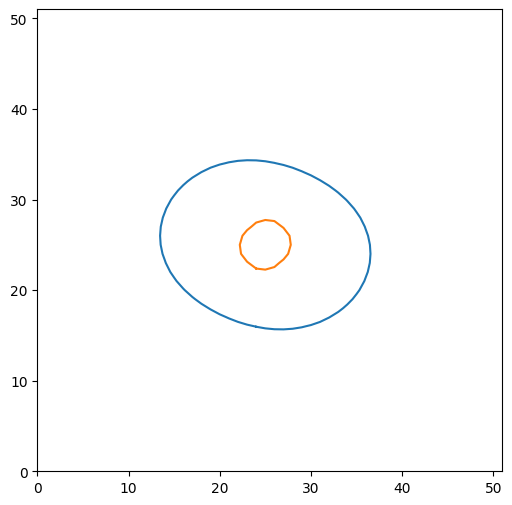

In [ ]:
plt.figure(figsize=(6,6))
critical_curves = df.get_critical_curves()
for polygon in critical_curves:
    plt.plot(polygon[:, 0], polygon[:,1], '-')

plt.xlim(0, 51)
plt.ylim(0, 51)
plt.show()

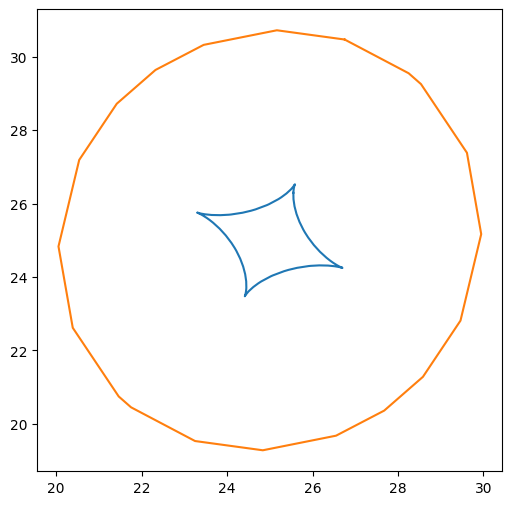

In [ ]:
plt.figure(figsize=(6,6))
caustics = df.get_caustics()

for polygon in caustics:
    plt.plot(polygon[:, 0], polygon[:, 1])
plt.show()

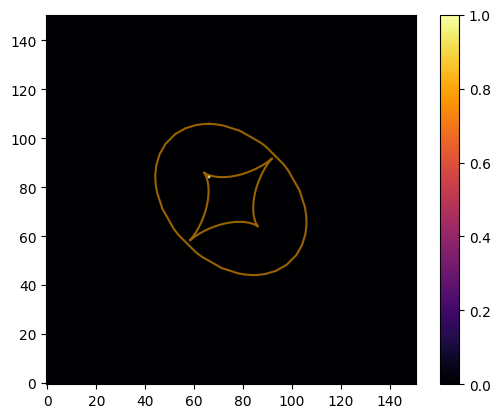

In [ ]:
# %matplotlib qt
arr = np.zeros((151,151))
arr[84,66]=1

src = Source(arr)
df = PIEMD(src, theta_E=30, q=0.5, s=1, phi=np.pi/4)

caustics = df.get_caustics()

cbar = plt.imshow(df.source.array, cmap='inferno', origin='lower')
plt.colorbar(cbar)

for curve in caustics:
    plt.plot(curve[:,0], curve[:,1], c='orange', alpha=0.6)

plt.show()

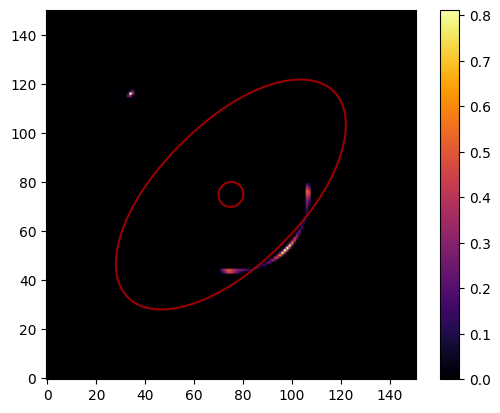

In [ ]:
cbar = plt.imshow(df.get_image(), cmap='inferno', origin='lower')
plt.colorbar(cbar)

for curve in df.get_critical_curves():
    plt.plot(curve[:,0], curve[:,1], c='red', alpha=0.6)

plt.show()

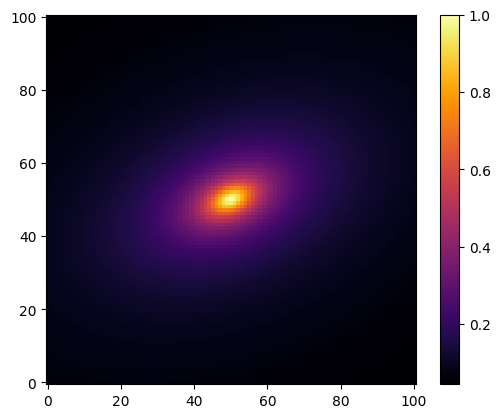

In [ ]:
arr = np.zeros((101,101))

src = Source(arr)
df = PIEMD(src,theta_E=10, q=0.6, s=5, phi=np.pi/8)

cbar=plt.imshow(df.generate_lens(), cmap='inferno', origin='lower')
plt.colorbar(cbar)
plt.show()

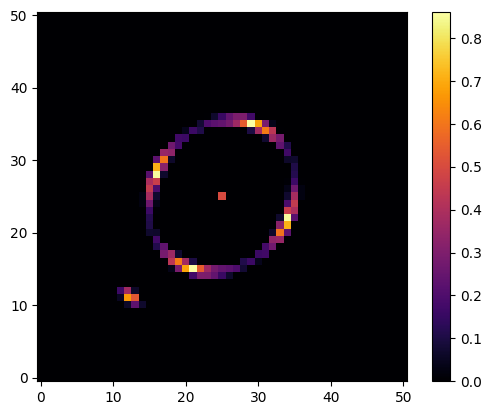

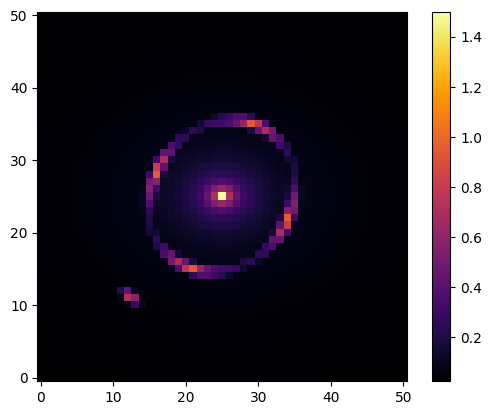

In [ ]:
arr = np.zeros((51,51))
arr[25,25] = 1
arr[20,20] = 1
src = Source(arr)
df = PIEMD(src, theta_E=10, q=0.8, s=1, gamma_1=0.01, gamma_2=0.03)

img = df.get_image()
img[25,25]=0.5

lens = df.generate_lens()
lens = lens/np.max(lens)

cbar=plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar(cbar)
plt.show()

cbar=plt.imshow(lens+img, cmap='inferno', origin='lower')
plt.colorbar(cbar)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource

import scipy as sp

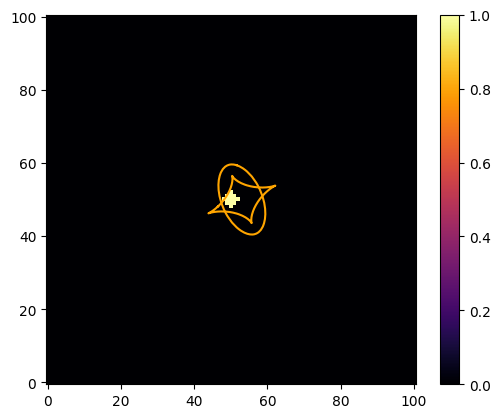

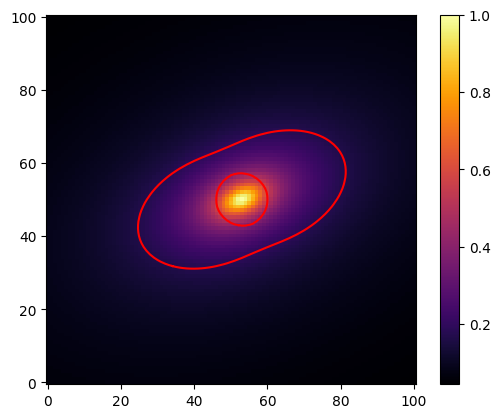

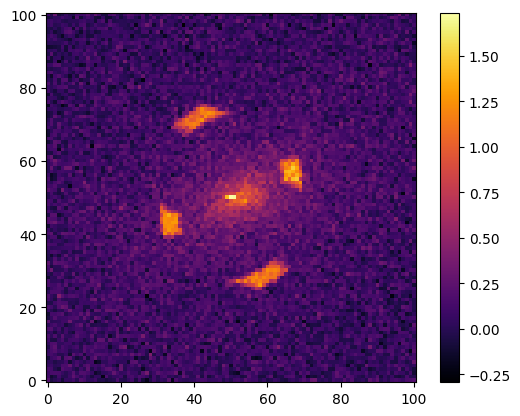

In [ ]:
src = DiskSource(101, 2)
df = PIEMD(src,theta_E=20, q=0.6, s=5, phi=np.pi/8)
df.align_source(cx=53,cy=50)

df.plot_source(caustics=True)
df.plot_image(lens=True,image=False, critical_curves=True)
df.plot_image(noise=True)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource

import scipy as sp

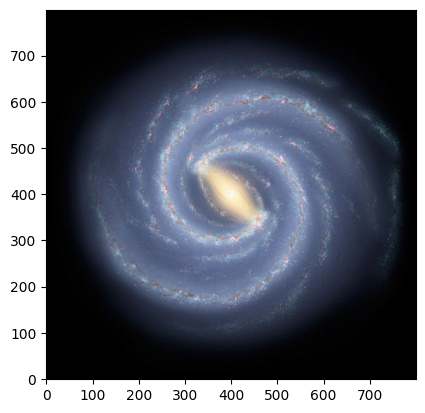

In [ ]:
from PIL import Image

img = Image.open("figures_in/Milky_Way_illustration-1.jpeg")
arr = np.array(img)

plt.imshow(arr, origin='lower')
plt.show()

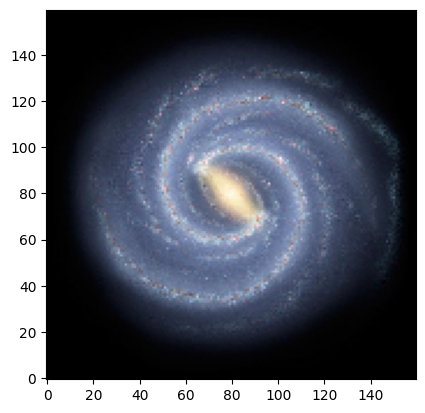

In [ ]:
z = 0.2
arr_zoom = sp.ndimage.zoom(arr, (z,z,1))

plt.imshow(arr_zoom, origin='lower')
plt.show()

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

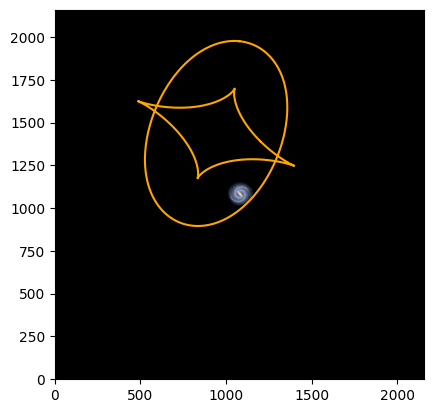

In [ ]:
src = Source(arr_zoom)
src.pad(1000)
df = PIEMD(src, theta_E=400, q=0.4, s=10, phi=-np.pi/8)
df.align_source(cx=942, cy=1436)

df.plot_source(caustics=True)

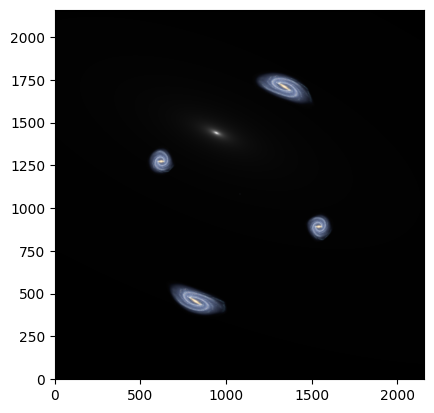

In [ ]:
df.plot_image()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource
import scipy as sp
from PIL import Image

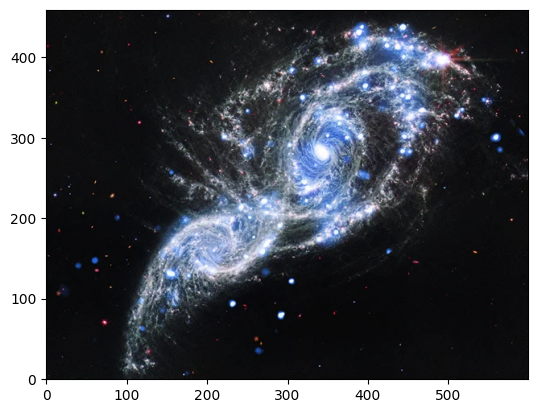

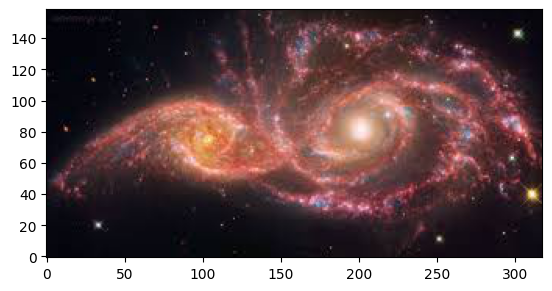

In [ ]:
img = Image.open("figures_in/g1.jpeg")
g1 = np.array(img)

img = Image.open("figures_in/g2.jpeg")
g2 = np.array(img)

plt.imshow(g1, origin="lower")
plt.show()

plt.imshow(g2, origin="lower")
plt.show()

In [ ]:
src1 = Source(g1)
src2 = Source(g2)

df1 = PIEMD(src1, s=100)
df2 = PIEMD(src2, s=100)

pad=1200
df1.pad_source(pad)
df2.pad_source(pad)

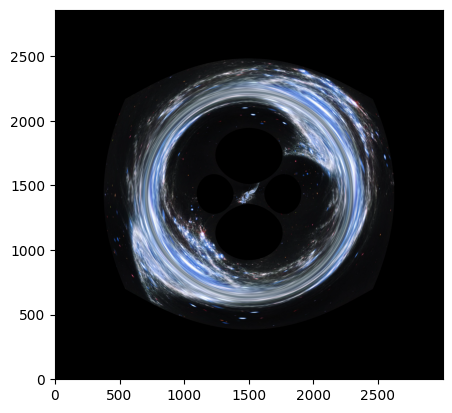

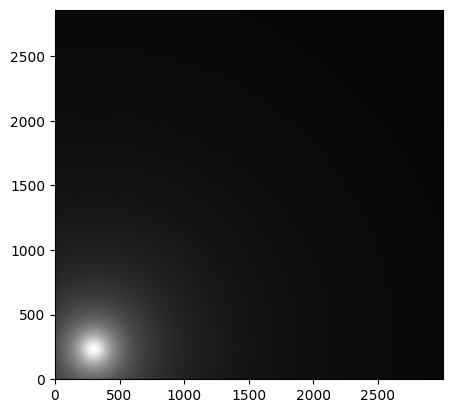

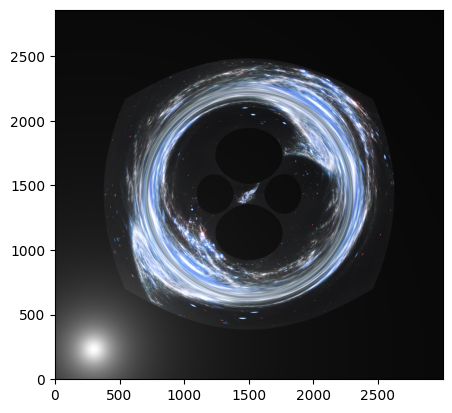

In [ ]:
df1.plot_image(lens=False, image=True)
df1.plot_image(lens=True, image=False)
df1.plot_image(lens=True, image=True)

# I want to try on hubble deep field

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource
import scipy as sp
from PIL import Image

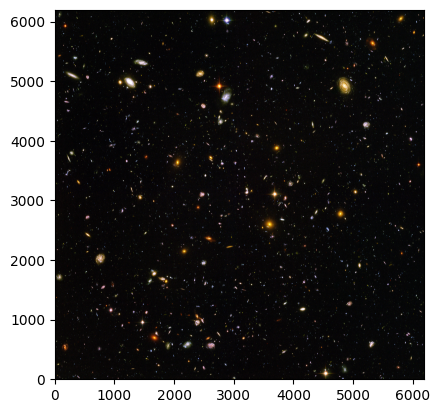

In [2]:
image = Image.open("figures_in/Hubble_ultra_deep_field_high_rez_edit1.jpg")
img = np.array(image)
plt.imshow(img, origin='lower')
plt.show()

In [ ]:
# %matplotlib qt
# import matplotlib.pyplot as plt

# plt.imshow(arr, origin='lower')
# plt.show()

In [3]:
src = Source(img)
df = PIEMD(src, theta_E=30, q=0.3, s=10, phi=-np.pi/8)
df.align_source(cx=4877, cy=1093)

arr = df.get_image()

In [4]:
%matplotlib qt
import matplotlib.pyplot as plt

df.plot_image(lens=True, image=True, I_0=5)

TypeError: PIEMD.plot_image() got an unexpected keyword argument 'I_0'

In [6]:
plt.close()